<a href="https://colab.research.google.com/github/ARUNREDDYPOREDDY/EXPLAINABLE-AI/blob/main/XAI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Load dataset
file_path = '/content/archive.zip'
df = pd.read_csv(file_path)

# Drop irrelevant columns
df = df.drop(['eid', 'vdate', 'discharged', 'facid'], axis=1)

# Fix 'rcount' column: convert '5+' to 5
df['rcount'] = df['rcount'].replace('5+', '5').astype(float)

# Encode categorical variables
label_encoders = {}
for col in ['gender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Handle missing values
imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Separate features and target
X = df.drop('lengthofstay', axis=1)
y = df['lengthofstay']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

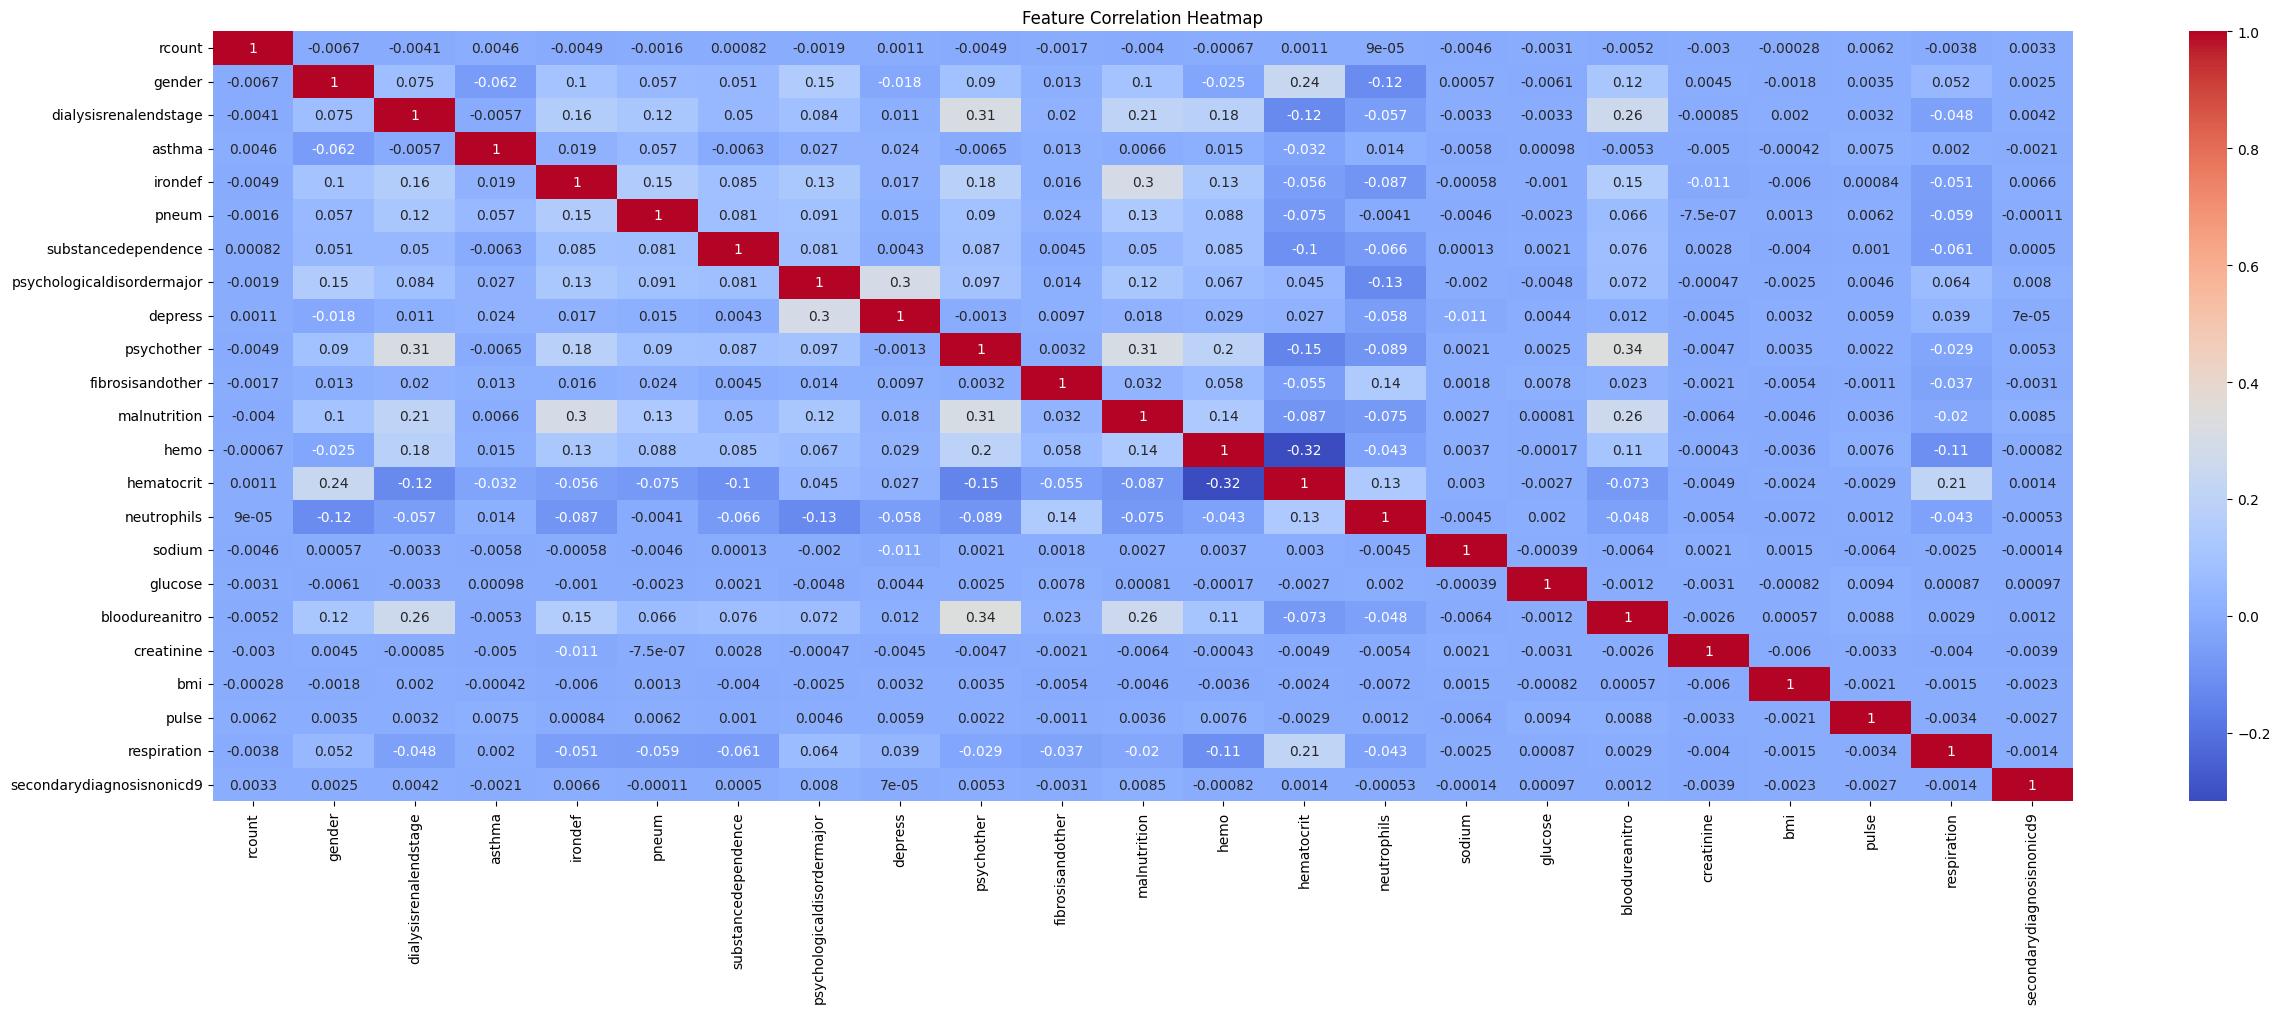

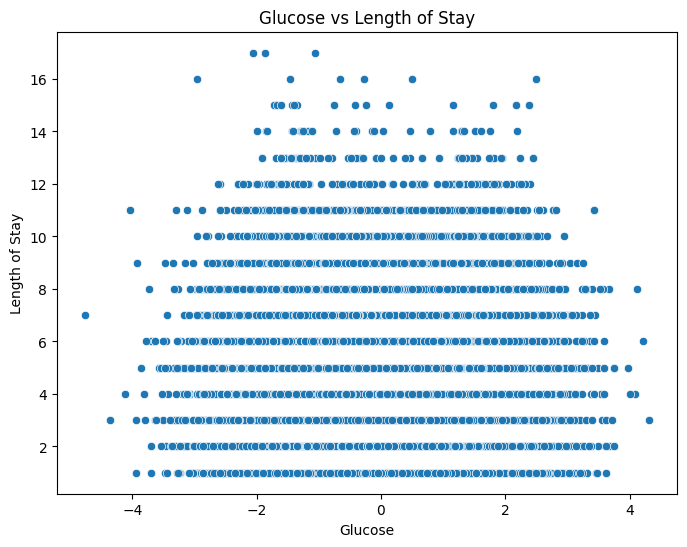

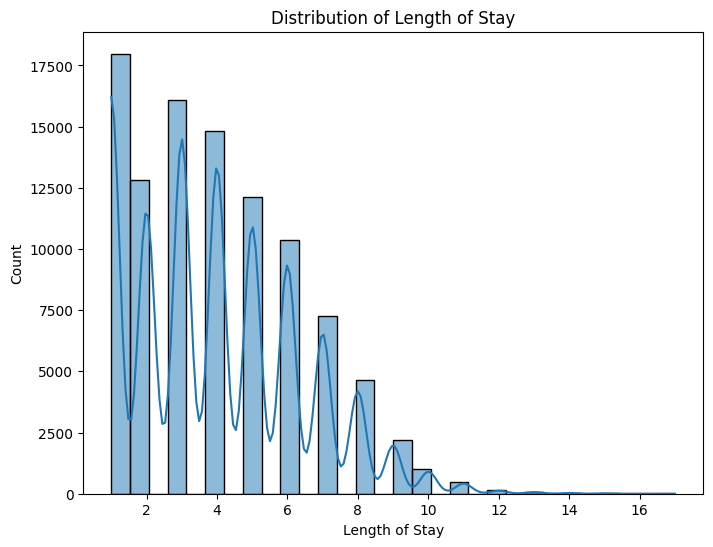

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Correlation heatmap
plt.figure(figsize=(30, 10))
sns.heatmap(pd.DataFrame(X_train, columns=X.columns).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Scatter plot example
# Get the index of the 'glucose' column from the original DataFrame's columns
glucose_col_index = X.columns.get_loc('glucose')

plt.figure(figsize=(8, 6))
# Use the scaled training data and the index of the 'glucose' column
sns.scatterplot(x=X_train[:, glucose_col_index], y=y_train)
plt.xlabel('Glucose')
plt.ylabel('Length of Stay')
plt.title('Glucose vs Length of Stay')
plt.show()

# Imbalance analysis
plt.figure(figsize=(8, 6))
sns.histplot(y, bins=30, kde=True)
plt.xlabel('Length of Stay')
plt.title('Distribution of Length of Stay')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
print('Random Forest MAE:', mean_absolute_error(y_test, y_pred_rf))
print('Random Forest RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print('Random Forest R2:', r2_score(y_test, y_pred_rf))

Random Forest MAE: 0.38028949999999995
Random Forest RMSE: 0.630473405466083
Random Forest R2: 0.9275592330312056


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)  # Regression output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate
y_pred_dl = model.predict(X_test).flatten()
print('Deep Learning MAE:', mean_absolute_error(y_test, y_pred_dl))
print('Deep Learning RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_dl)))
print('Deep Learning R2:', r2_score(y_test, y_pred_dl))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 2.5396 - mae: 1.0936 - val_loss: 0.9390 - val_mae: 0.6656
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 1.0348 - mae: 0.7391 - val_loss: 0.8492 - val_mae: 0.6284
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.9188 - mae: 0.6897 - val_loss: 0.9429 - val_mae: 0.6634
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.8169 - mae: 0.6531 - val_loss: 0.9950 - val_mae: 0.6976
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7900 - mae: 0.6393 - val_loss: 0.7724 - val_mae: 0.6119
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7493 - mae: 0.6205 - val_loss: 0.8139 - val_mae: 0.6241
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7045 - mae: 0.6053 - val_loss: 0.8657 - val_mae: 0.6483
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6894 - mae: 0.5969 - val_loss: 0.7257 - val_mae: 0.5850
Epoch 9/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/st

Random Forest MAE: 0.38028949999999995
Random Forest RMSE: 0.630473405466083
Random Forest R2: 0.9275592330312056


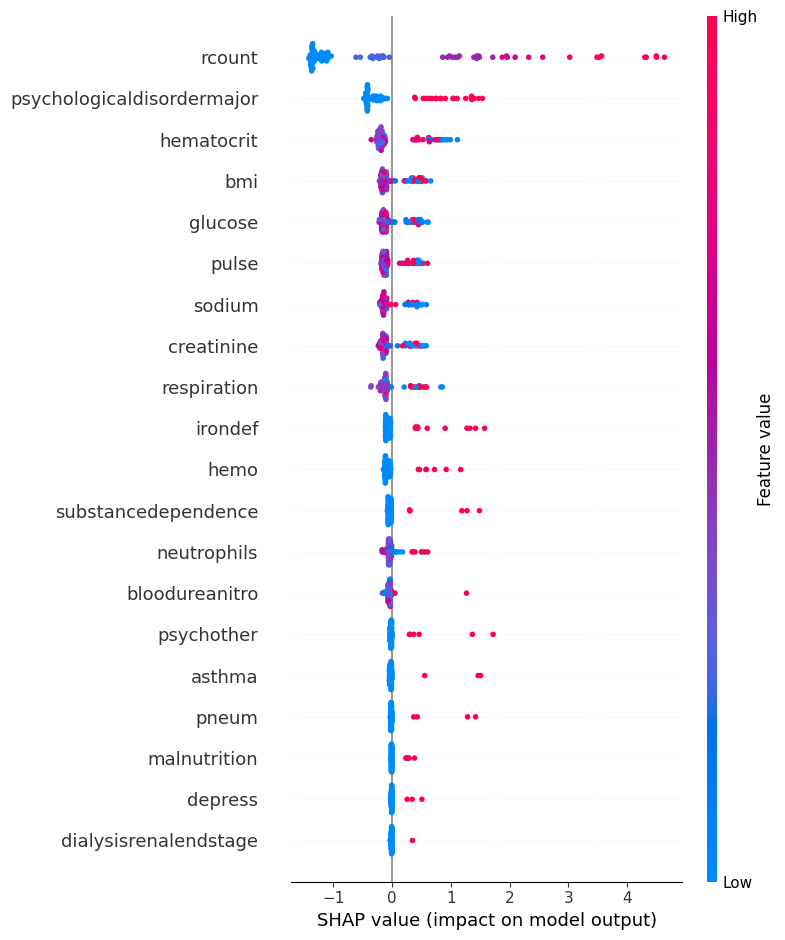

In [ ]:
import zipfile
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Extract and load dataset
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/extracted/')

file_path = '/content/extracted/LengthOfStay.csv'
df = pd.read_csv(file_path)

# Drop irrelevant columns
df = df.drop(['eid', 'vdate', 'discharged', 'facid'], axis=1)

# Fix 'rcount' column
df['rcount'] = df['rcount'].replace('5+', '5').astype(float)

# Encode categorical variables
label_encoders = {}
for col in ['gender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Handle missing values
imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Separate features and target
X = df.drop('lengthofstay', axis=1)
y = df['lengthofstay']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Print Metrics
print('Random Forest MAE:', mean_absolute_error(y_test, y_pred_rf))
print('Random Forest RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print('Random Forest R2:', r2_score(y_test, y_pred_rf))

# Efficient SHAP Explanation using sample size of 100
explainer = shap.TreeExplainer(rf)

# Sample first 100 rows of test set
sample_size = 100
X_test_sample = X_test[:sample_size]

# Calculate SHAP values on the sample
shap_values = explainer.shap_values(X_test_sample)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)


In [ ]:
!pip install pdpbox

After installing, please run the cell with the error again.

In [ ]:
!pip install pdpbox==0.2.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 MB 4.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


Available features: ['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9']


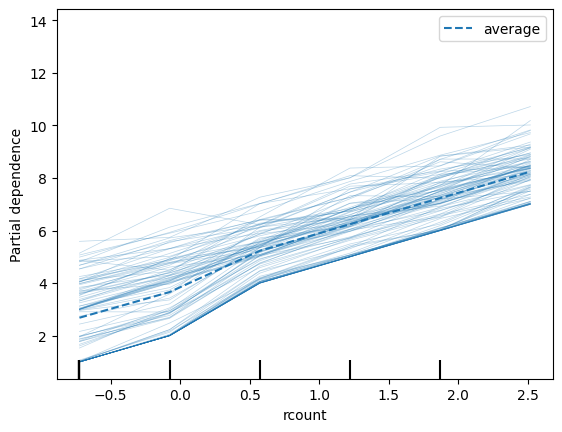

In [ ]:
import pandas as pd
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Convert scaled arrays back to DataFrames with column names
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# PDP + ICE for one feature (replace 'glucose' with any actual column in your dataset)
feature_name = X.columns[0]   # just pick the first feature if you're not sure
print("Available features:", list(X.columns))  # check which names exist

PartialDependenceDisplay.from_estimator(
    rf,
    X_test_df,
    [feature_name],   # e.g., 'glucose' if it exists, otherwise use one from the print above
    kind="both",
    subsample=100,
    random_state=42
)
plt.show()


Top features: ['rcount', 'psychologicaldisordermajor', 'hematocrit', 'hemo', 'bmi']

PDP + ICE for feature: rcount


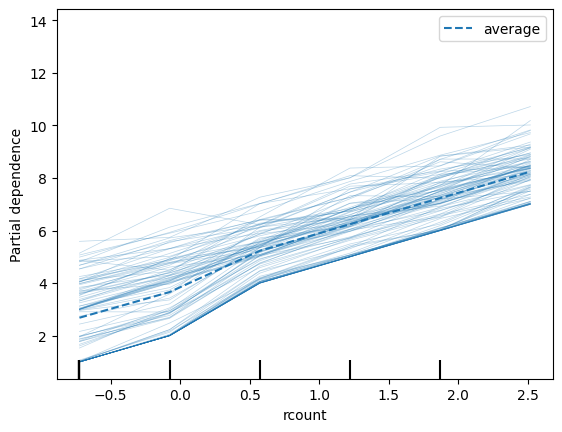


PDP + ICE for feature: psychologicaldisordermajor


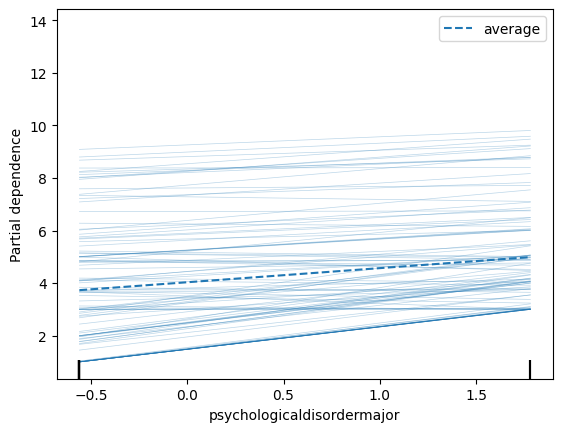


PDP + ICE for feature: hematocrit


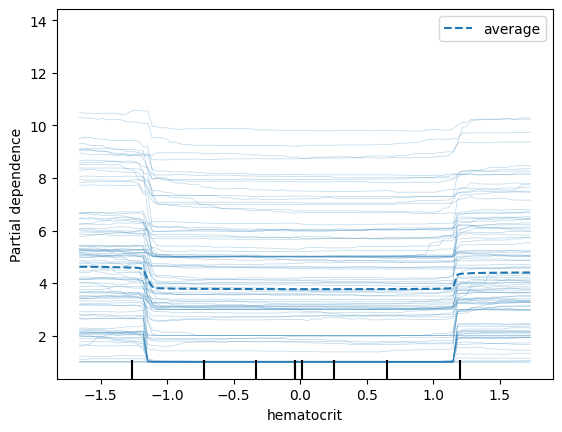


PDP + ICE for feature: hemo


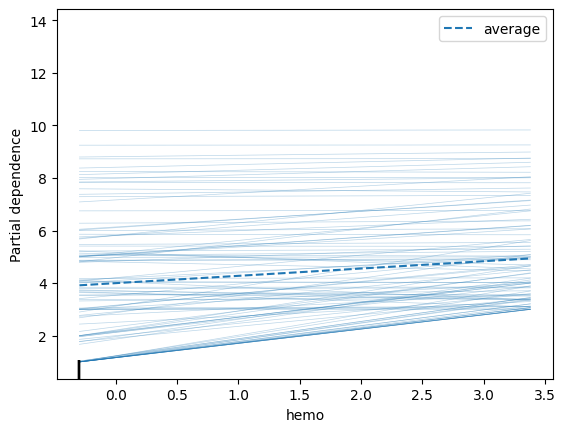


PDP + ICE for feature: bmi


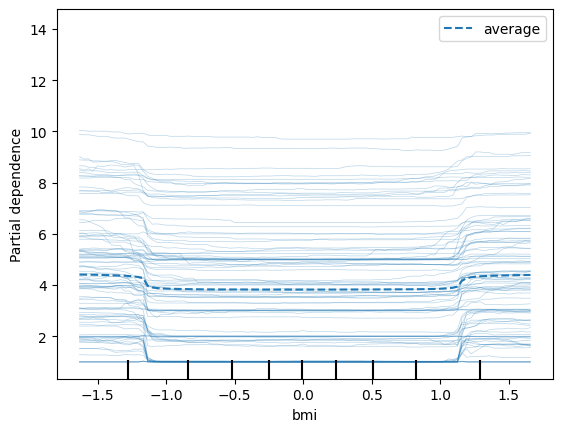

In [ ]:
import numpy as np

# Get feature importances from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

# Pick top 5 features
top_n = 5
top_features = [X.columns[i] for i in indices[:top_n]]
print("Top features:", top_features)

# Plot PDP + ICE for each top feature
for feature in top_features:
    print(f"\nPDP + ICE for feature: {feature}")
    PartialDependenceDisplay.from_estimator(
        rf,
        X_test_df,
        [feature],
        kind="both",  # PDP + ICE
        subsample=100,
        random_state=42
    )
    plt.show()
